In [ ]:
# Bacis libraries
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter("ignore", pd.errors.DtypeWarning)

# Statistics
from scipy.stats import pearsonr
import dcor

# Plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# Normalizer
from sklearn.preprocessing import StandardScaler

# Helper functions
from helper_functions import (
    load_signal_data,
    extract_operating_periods,
    find_pelt_change_points,
    extract_steady_states,
    test_dbscan_eps,
    make_window_features,
    clean_signals,
    correlate_with_vibration
)

In [2]:
folder = "step_interpolation_10s/G2_relevant"

dfs = load_signal_data(
    search_folder=folder
)

In [4]:
dfs, cleaning_table = clean_signals(dfs)

cleaning_table

,Signal,Invalid values,Invalid [%]
0,Trykk i turbininnløp Middelverdi (Hydrocord),759,0.0578
1,G2 Lagerolje DE temp.,10,0.0008
2,G2 Lagertemp. 2 DE radial,4,0.0003


In [ ]:
speed_name = "Turbin 2 Turtall"
power_name = "G2 Generator aktiv effekt [MW]"

speed = dfs.loc[dfs["name"] == speed_name, "signal_df"].iloc[0]
power = dfs.loc[dfs["name"] == power_name, "signal_df"].iloc[0]

In [ ]:
operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30
)

print("Number of operating periods:", len(operating_periods))
operating_periods.head()

Number of operating periods: 59


,start_time,end_time,n_samples
0,2024-06-01 00:00:00,2024-06-01 12:36:50,4542
1,2024-06-01 13:55:20,2024-06-03 07:38:30,15020
2,2024-06-03 08:01:10,2024-06-03 12:49:10,1729
3,2024-06-03 13:12:20,2024-06-03 17:54:30,1694
4,2024-06-03 19:08:40,2024-06-08 08:57:00,39531


In [4]:
pelt_times = find_pelt_change_points(
    power_df=power,
    operating_periods=operating_periods,
    min_samples=3,
    n_periods=6
)

print("PELT breakpoints:", len(pelt_times))

PELT breakpoints: 60


In [ ]:
power_name = "G2 Generator aktiv effekt [MW]"
vib_name = "G2 Vibrasjon D.E"

power = dfs.loc[dfs["name"] == power_name, "signal_df"].iloc[0]
vib = dfs.loc[dfs["name"] == vib_name, "signal_df"].iloc[0]

plot_start = pd.Timestamp("2024-06-01 00:20:00")
plot_end = plot_start + pd.Timedelta(hours=20, minutes=10)

power_plot = power[power["Datetime"].between(plot_start, plot_end)]
vib_plot = vib[vib["Datetime"].between(plot_start, plot_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(power_plot["Datetime"], power_plot["signal"], label="Active power")
axes[1].plot(vib_plot["Datetime"], vib_plot["signal"], label="Vibration")

axes[0].set_ylabel("Power [MW]")
axes[1].set_ylabel("Vibration [RMS mm/s]")
axes[1].set_xlabel("Time")

# Operating period start/end
for _, period in operating_periods.iterrows():
    for t in [period["start_time"], period["end_time"]]:
        if plot_start <= t <= plot_end:
            axes[0].axvline(t, color="black", linestyle="--", alpha=0.7)
            axes[1].axvline(t, color="black", linestyle="--", alpha=0.7)

# PELT breakpoints
for t in pelt_times:
    if plot_start <= t <= plot_end:
        axes[0].axvline(t, color="red", linestyle="--", alpha=0.7)
        axes[1].axvline(t, color="red", linestyle="--", alpha=0.7)

# Labels for vertical lines
axes[0].plot([], [], color="black", linestyle="--", label="Operating start/end")
axes[0].plot([], [], color="red", linestyle="--", label="PELT breakpoint")

for ax in axes:
    ax.grid(True)
    ax.legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle("Power and vibration with operating periods and PELT breakpoints")
plt.tight_layout()

plt.savefig("power_vibration_pelt_breakpoints.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
windows = make_window_features(
    power_df=power,
    operating_periods=operating_periods,
    window_size=6,
    n_periods=6
)

In [ ]:
X = windows[["mean_power", "std_power"]]
X_scaled = StandardScaler().fit_transform(X)

eps_results = test_dbscan_eps(
    X_scaled,
    eps_start=0.05,
    eps_stop=0.35,
    eps_step=0.02,
    min_samples=5
)

eps_results

,eps,n_clusters,noise_percent
0,0.05,52,3.592446
1,0.06,30,2.652613
2,0.07,15,2.134387
3,0.08,7,1.607378
4,0.09,5,1.519543
5,0.10,5,1.370224
6,0.11,6,1.264822
7,0.12,7,1.194554
8,0.13,6,1.141853
9,0.14,6,1.097936


In [41]:
windows, steady_intervals, X_scaled = extract_steady_states(
    power_df=power,
    operating_periods=operating_periods,
    eps=0.22,
    min_samples=5,
    window_size=6,
    n_periods=6
)

In [42]:
summary = (
    windows
    .groupby("cluster")
    .agg(
        n_windows=("cluster", "size"),
        mean_power=("mean_power", "mean"),
        mean_std_power=("std_power", "mean"),
        min_power=("mean_power", "min"),
        max_power=("mean_power", "max")
    )
    .sort_index()
)

summary

,n_windows,mean_power,mean_std_power,min_power,max_power
cluster,,,,,
-1,95,5.646070,0.315202,0.536667,10.205
0,10907,8.795900,0.004353,5.100000,10.410
1,269,3.951883,0.001299,3.690000,4.060
2,114,0.872939,0.003263,0.690000,1.080


In [43]:
clusters = sorted(windows["cluster"].unique())

base_colors = [
    "tab:orange",
    "tab:green",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan"
]

cluster_colors = {}

for i, cluster in enumerate(clusters):
    if cluster == -1:
        cluster_colors[cluster] = "tab:blue"   # noise color
    else:
        cluster_colors[cluster] = base_colors[i % len(base_colors)]

noise_handle = mpatches.Patch(color="tab:blue", label="Noise")

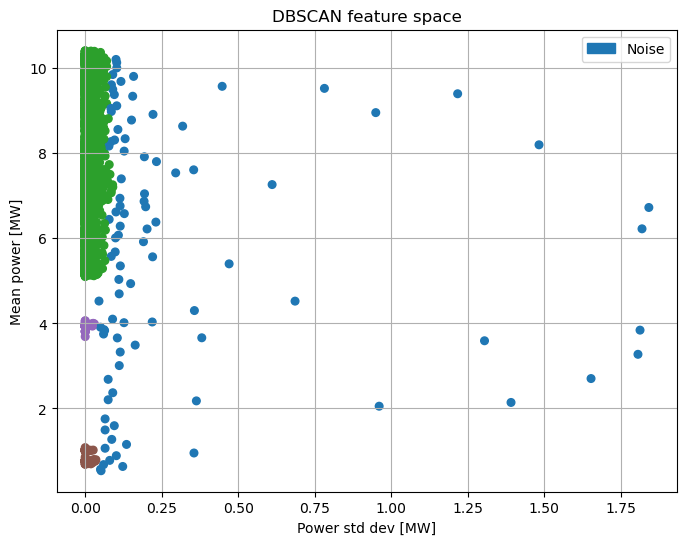

In [44]:
point_colors = windows["cluster"].map(cluster_colors)

plt.figure(figsize=(8, 6))

plt.scatter(
    windows["std_power"],
    windows["mean_power"],
    c=point_colors,
    s=30
)

plt.legend(handles=[noise_handle])

plt.xlabel("Power std dev [MW]")
plt.ylabel("Mean power [MW]")
plt.title("DBSCAN feature space")
plt.grid(True)
plt.show()

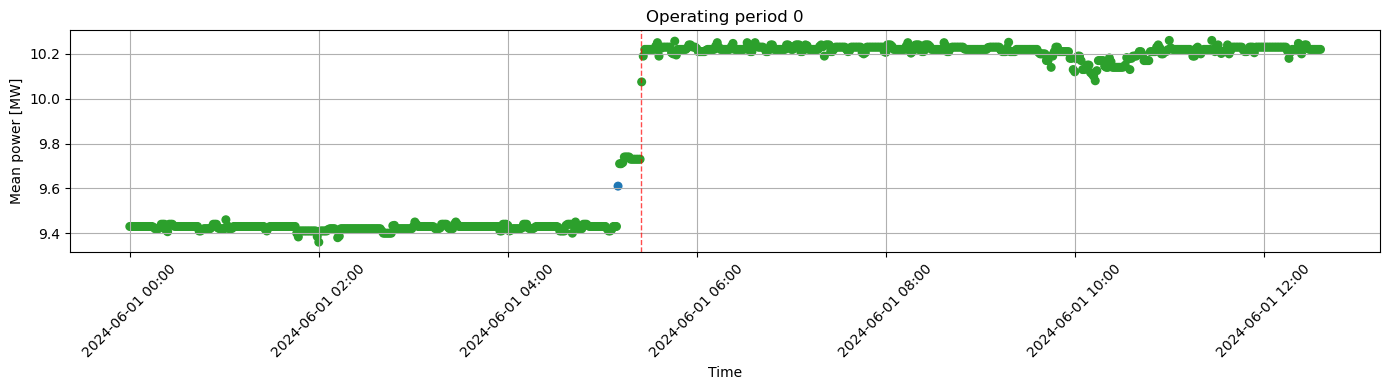

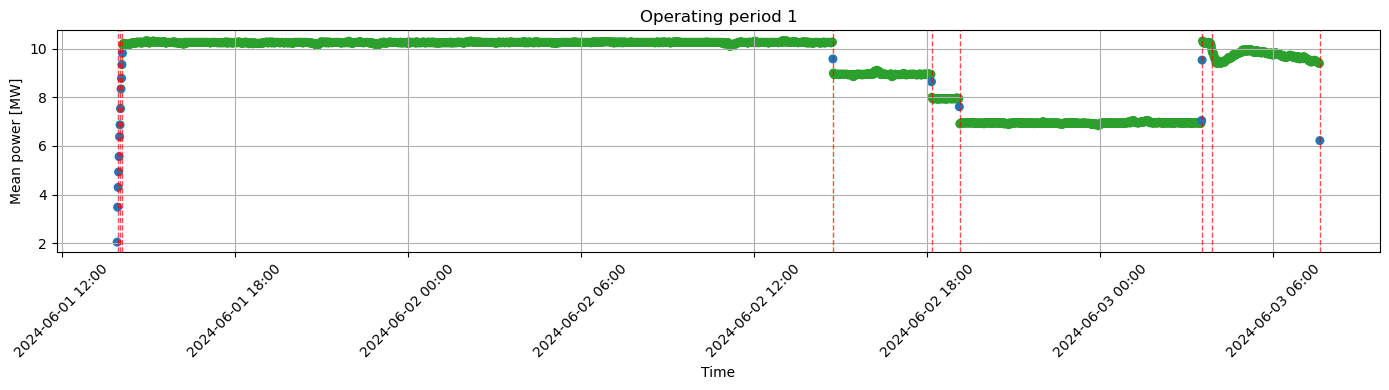

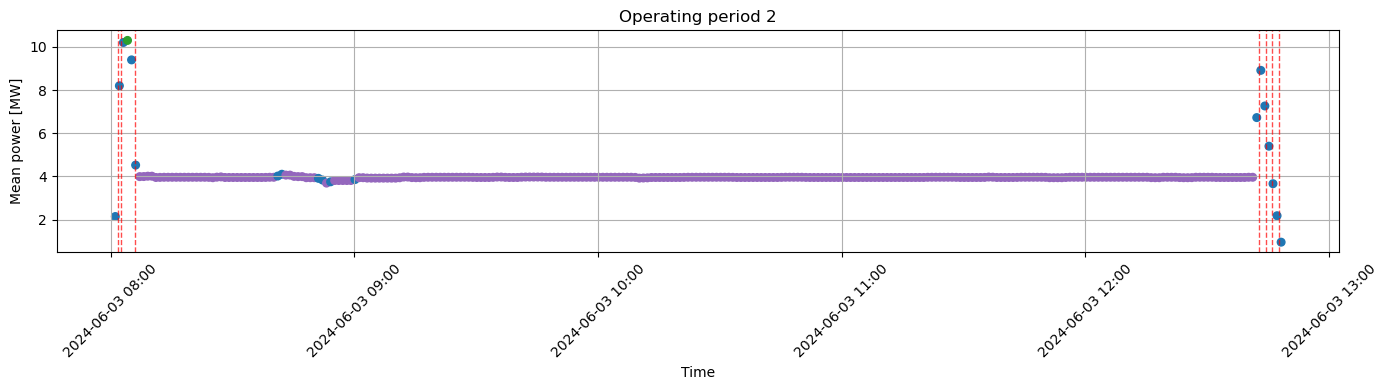

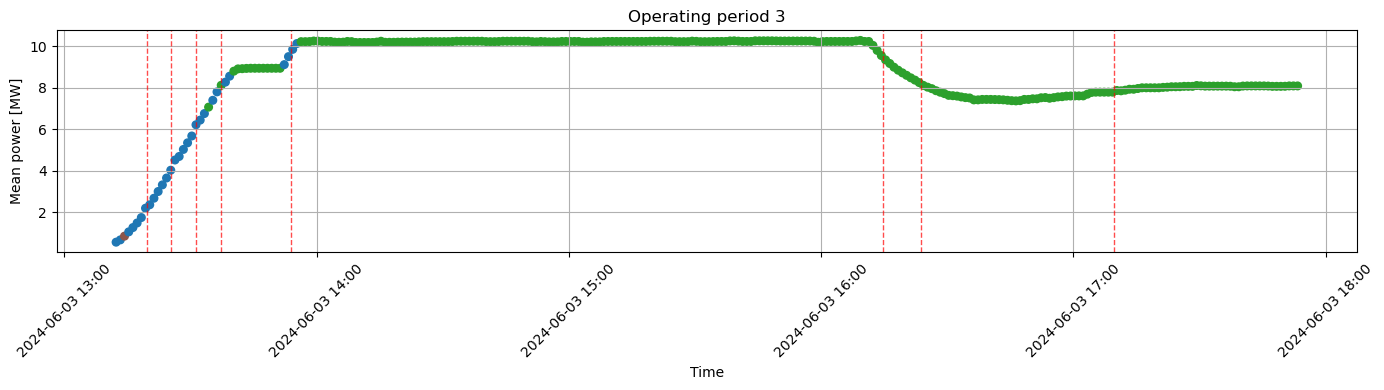

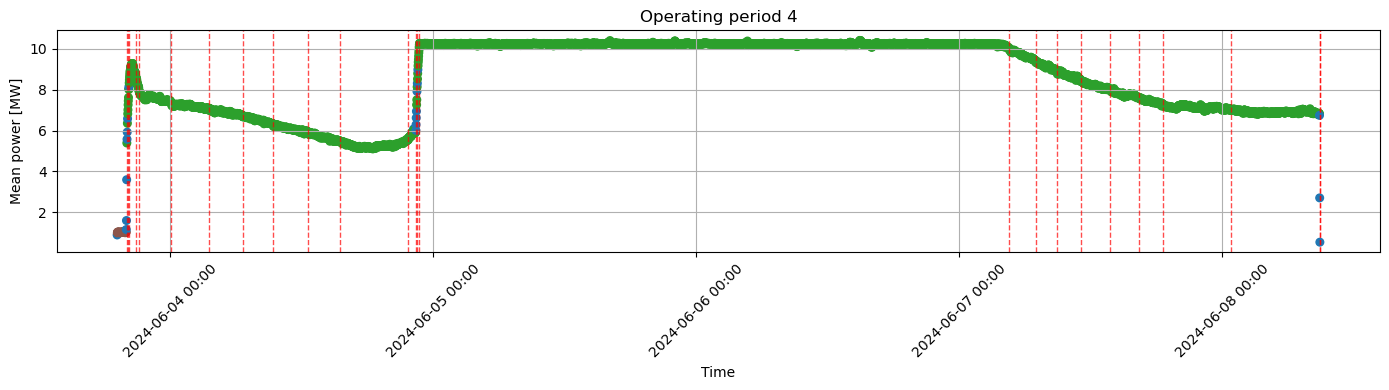

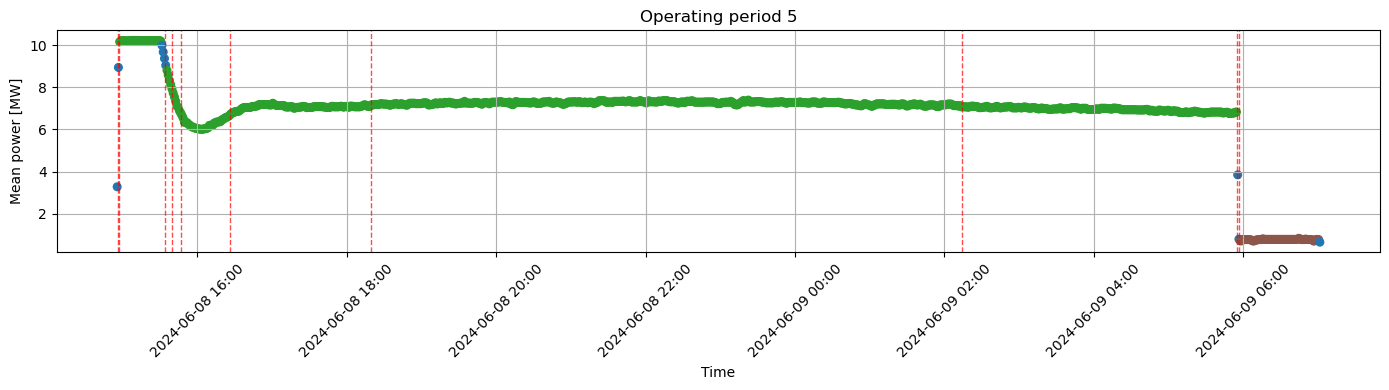

In [45]:
for op in sorted(windows["operating_period"].unique()):
    temp = windows[windows["operating_period"] == op]
    temp_colors = temp["cluster"].map(cluster_colors)

    plt.figure(figsize=(14, 4))

    plt.scatter(
        temp["start_time"],
        temp["mean_power"],
        c=temp_colors,
        s=30
    )

    for t in pelt_times:
        if temp["start_time"].min() <= t <= temp["end_time"].max():
            plt.axvline(t, color="red", linestyle="--", linewidth=1, alpha=0.7)

    plt.xlabel("Time")
    plt.ylabel("Mean power [MW]")
    plt.title(f"Operating period {op}")
    plt.grid(True)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [1]:
vib_name = "G2 Vibrasjon D.E"

vib = dfs.loc[dfs["name"] == vib_name, "signal_df"].iloc[0]

# Get all operating timestamps
operating_times = pd.concat([
    power.loc[
        power["Datetime"].between(row["start_time"], row["end_time"]),
        ["Datetime"]
    ]
    for _, row in operating_periods.iterrows()
]).drop_duplicates()

# Vibration only during operating periods
vib_operating = (
    operating_times
    .merge(vib, on="Datetime")
    .rename(columns={"signal": vib_name})
)

results = []

for _, row in dfs.iterrows():
    name = row["name"]

    if name == vib_name:
        continue

    data = (
        vib_operating
        .merge(row["signal_df"], on="Datetime")
        .rename(columns={"signal": name})
        .dropna()
    )

    if len(data) < 2:
        continue

    results.append({
        "Signal": name,
        "Pearson": pearsonr(data[vib_name], data[name])[0],
        "Distance": dcor.distance_correlation(data[vib_name], data[name])
    })

corr_df = (
    pd.DataFrame(results)
    .sort_values("Distance", ascending=False)
)

corr_df

NameError: name 'dfs' is not defined

In [ ]:
x = np.arange(len(corr_df))
w = 0.35

plt.figure(figsize=(16, 7))

plt.bar(x - w/2, corr_df["Distance"], width=w, label="Distance correlation")
plt.bar(x + w/2, corr_df["Pearson"], width=w, label="Pearson correlation")

plt.xticks(x, corr_df["Signal"], rotation=75, ha="right")
plt.ylabel("Correlation coefficient")
plt.title("Correlation with vibration during operating periods")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()

plt.savefig("correlation_with_vibration_operating_periods.png", dpi=300, bbox_inches="tight")
plt.show()